In [14]:
import pandas as pd
import numpy as np
from gensim.corpora import Dictionary
from gensim.models.ldamulticore import LdaMulticore
from gensim.models.coherencemodel import CoherenceModel
import re
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

def lda_topic_modeling_analysis_robust(text_data, max_topics=11):
    """Robust LDA analysis with comprehensive error handling"""
    
    print("🚀 ROBUST LDA TOPIC MODELING ANALYSIS")
    print("=" * 50)
    
    print(f"✅ Loaded {len(text_data)} documents")
    
    # Enhanced preprocessing
    def preprocess_robust(text):
        if pd.isna(text) or str(text).strip() == '':
            return []
        
        # Convert to lowercase and remove punctuation
        text = re.sub(r'[^a-zA-Z\s]', '', str(text).lower())
        
        # Split into words
        words = text.split()
        
        # Enhanced stop words list
        stop_words = {
            'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 'of', 
            'with', 'by', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 
            'has', 'had', 'do', 'does', 'did', 'will', 'would', 'could', 'should', 
            'may', 'might', 'must', 'can', 'this', 'that', 'these', 'those', 'i', 
            'you', 'he', 'she', 'it', 'we', 'they', 'me', 'him', 'her', 'us', 'them',
            'about', 'into', 'through', 'during', 'before', 'after', 'above', 'below',
            'up', 'down', 'out', 'off', 'over', 'under', 'again', 'further', 'then', 'once'
        }
        
        # Filter words
        words = [w for w in words if w not in stop_words and len(w) > 2]
        return words
    
    # Process documents
    print("🔧 Processing documents...")
    processed_docs = [preprocess_robust(doc) for doc in text_data]
    
    # Remove empty documents
    original_count = len(processed_docs)
    processed_docs = [doc for doc in processed_docs if doc and len(doc) > 0]
    valid_count = len(processed_docs)
    
    print(f"📊 Documents after preprocessing: {valid_count}/{original_count}")
    
    if valid_count < 3:
        print("❌ Not enough valid documents for LDA. Need at least 3 documents with content.")
        return None, None, None
    
    # Create dictionary and corpus
    try:
        dictionary = Dictionary(processed_docs)
        print(f"📚 Dictionary created with {len(dictionary)} unique tokens")
        
        # Filter extremes
        dictionary.filter_extremes(no_below=2, no_above=0.8, keep_n=1000)
        print(f"📚 Dictionary after filtering: {len(dictionary)} tokens")
        
        if len(dictionary) < 10:
            print("❌ Dictionary too small after filtering. Try with more diverse text.")
            return None, None, None
        
        corpus = [dictionary.doc2bow(doc) for doc in processed_docs]
        
        # Remove empty documents from corpus
        corpus = [doc for doc in corpus if doc]
        
        if len(corpus) < 3:
            print("❌ Corpus too small after filtering.")
            return None, None, None
            
        print(f"✅ Corpus created with {len(corpus)} documents")
        
    except Exception as e:
        print(f"❌ Error creating dictionary/corpus: {e}")
        return None, None, None
    
    # Find optimal number of topics with robust error handling
    print(f"\n🎯 Testing LDA topics (2 to {max_topics})...")
    
    lda_results = []
    successful_models = 0
    
    print(f"{'Topics':>6} {'Status':>10} {'Coherence':>10} {'Quality':>10}")
    print("-" * 45)
    
    for k in range(2, max_topics + 1):
        try:
            # Fit LDA model with conservative settings
            lda = LdaMulticore(
                corpus=corpus,
                id2word=dictionary,
                num_topics=k,
                passes=5,  # Reduced for stability
                workers=1,  # Single worker for stability
                alpha='auto',
                eta='auto',
                random_state=42,
                per_word_topics=True
            )
            
            # Calculate coherence
            coherence_model = CoherenceModel(
                model=lda, 
                texts=processed_docs, 
                dictionary=dictionary, 
                coherence='c_v'
            )
            coherence = coherence_model.get_coherence()
            
            # Quality assessment
            if coherence > 0.6:
                quality = "Excellent"
            elif coherence > 0.4:
                quality = "Good"
            elif coherence > 0.2:
                quality = "Fair"
            else:
                quality = "Poor"
            
            lda_results.append({
                'k': k,
                'coherence': coherence,
                'quality': quality,
                'model': lda
            })
            
            successful_models += 1
            print(f"{k:>6} {'Success':>10} {coherence:>10.3f} {quality:>10}")
            
        except Exception as e:
            print(f"{k:>6} {'Failed':>10} {'N/A':>10} {'Error':>10}")
            continue
    
    # Check if we have any successful models
    if not lda_results or len(lda_results) == 0:
        print(f"\n❌ No valid LDA models created out of {max_topics-1} attempts.")
        return None, None, None
    
    print(f"\n✅ Successfully created {len(lda_results)} LDA models")
    
    # Select best model
    best_lda = max(lda_results, key=lambda x: x['coherence'])
    
    print(f"\n🏆 OPTIMAL LDA CONFIGURATION:")
    print(f"   Topics: {best_lda['k']}")
    print(f"   Coherence Score: {best_lda['coherence']:.3f}")
    print(f"   Quality: {best_lda['quality']}")
    
    # Get topic assignments with error handling
    topic_assignments = []
    topic_probs = []
    
    for i, bow in enumerate(corpus):
        try:
            doc_topics = best_lda['model'].get_document_topics(bow)
            if doc_topics:
                top_topic = max(doc_topics, key=lambda x: x[1])[0]
                topic_assignments.append(top_topic)
                topic_probs.append(doc_topics)
            else:
                topic_assignments.append(0)
                topic_probs.append([(0, 1.0)])
        except Exception as e:
            topic_assignments.append(0)
            topic_probs.append([(0, 1.0)])
    
    # Create results DataFrame
    valid_text_data = text_data[:len(topic_assignments)]
    
    results_df = pd.DataFrame({
        'Document': valid_text_data,
        'Top_Topic': topic_assignments
    })
    
    # Add probability columns
    for i in range(best_lda['k']):
        results_df[f'Topic_{i}_Probability'] = [
            dict(prob).get(i, 0.0) for prob in topic_probs
        ]
    
    # Analyze topics
    print(f"\n📊 LDA TOPIC ANALYSIS:")
    print("=" * 60)
    
    for topic_id in range(best_lda['k']):
        topic_count = (results_df['Top_Topic'] == topic_id).sum()
        print(f"\n🏷️  Topic {topic_id} - {topic_count} documents ({topic_count/len(results_df)*100:.1f}%)")
        
        print("   Top Terms:")
        try:
            terms = best_lda['model'].show_topic(topic_id, topn=5)
            for term, prob in terms:
                print(f"     {term} ({prob:.3f})")
        except:
            print("     Could not retrieve terms")
    
    # Export results
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    output_filename = f'lda_topic_modeling_{timestamp}.xlsx'
    
    try:
        with pd.ExcelWriter(output_filename, engine='openpyxl') as writer:
            results_df.to_excel(writer, sheet_name='Documents_with_Topics', index=False)
            
            # Topic summary
            topic_summary = []
            for topic_id in range(best_lda['k']):
                topic_count = (results_df['Top_Topic'] == topic_id).sum()
                
                try:
                    top_terms = ', '.join([f"{term} ({prob:.3f})" 
                                         for term, prob in best_lda['model'].show_topic(topic_id, topn=3)])
                except:
                    top_terms = "Could not retrieve terms"
                
                summary = {
                    'Topic_ID': topic_id,
                    'Num_Documents': topic_count,
                    'Percentage': f"{topic_count/len(results_df)*100:.1f}%",
                    'Top_Terms': top_terms
                }
                topic_summary.append(summary)
            
            summary_df = pd.DataFrame(topic_summary)
            summary_df.to_excel(writer, sheet_name='Topic_Summary', index=False)
        
        print(f"\n🎉 LDA ANALYSIS COMPLETE!")
        print(f"✅ {len(results_df)} documents modeled into {best_lda['k']} topics")
        print(f"📁 Results saved to: {output_filename}")
        
    except Exception as e:
        print(f"⚠️  Could not save Excel file: {e}")
    
    return results_df, best_lda['model'], output_filename

# YOUR CODE - Load Excel and convert to text
print("📁 Loading Excel data...")
df = pd.read_excel('./las3.18.xlsx')
print(f"✅ Loaded {len(df)} friends from Excel")

# Convert your structured data to text for LDA
print("🔄 Converting structured data to text...")
text_data = []
for _, row in df.iterrows():
    # Create meaningful text from your columns
    text = f"Professional in {row['Parent_Industry']} industry with {row['Turnover_Range']} revenue and {row['Employees_Range']} employees working as {row['Job_Function']} at {row['Job_Seniority']} level interested in {row['aoi_1']} {row['aoi_2']} {row['aoi_3']} {row['aoi_4']} {row['aoi_5']}"
    text_data.append(text)

print(f"✅ Created {len(text_data)} text documents")
print(f"📋 Sample text: {text_data[0]}")

# Run robust LDA
results_df, lda_model, results_file = lda_topic_modeling_analysis_robust(text_data, max_topics=12)

if results_df is not None:
    print("\n📋 SAMPLE RESULTS:")
    print(results_df[['Top_Topic']].head(10))
    
    # Also add the original ID for reference
    results_df['Unique_ID'] = df['Unique_ID']
    print("\n🆔 Sample with IDs:")
    print(results_df[['Unique_ID', 'Top_Topic']].head(10))
else:
    print("❌ LDA analysis failed.")


📁 Loading Excel data...
✅ Loaded 2425 friends from Excel
🔄 Converting structured data to text...
✅ Created 2425 text documents
📋 Sample text: Professional in Finance industry with 501 to 1000 Crs revenue and 5001 to 10000 Emp employees working as General Management at Executive level interested in Agentforce optimization  Marketing  Customer Engagement  Human-AI Interaction  Data-Driven AI
🚀 ROBUST LDA TOPIC MODELING ANALYSIS
✅ Loaded 2425 documents
🔧 Processing documents...
📊 Documents after preprocessing: 2425/2425
📚 Dictionary created with 81 unique tokens
📚 Dictionary after filtering: 69 tokens
✅ Corpus created with 2425 documents

🎯 Testing LDA topics (2 to 12)...
Topics     Status  Coherence    Quality
---------------------------------------------
     2     Failed        N/A      Error
     3     Failed        N/A      Error
     4     Failed        N/A      Error
     5     Failed        N/A      Error
     6     Failed        N/A      Error
     7     Failed        N/A      Er

In [ ]:
# Load your Excel data and convert to text
df = pd.read_excel('./las3.18.xlsx')

# Convert your structured data to text for LDA
text_data = []
for _, row in df.iterrows():
    # Create meaningful text from your columns
    text = f"Professional in {row['Parent_Industry']} industry with {row['Turnover_Range']} revenue and {row['Employees_Range']} employees working as {row['Job_Function']} at {row['Job_Seniority']} level interested in {row['aoi_1']} {row['aoi_2']} {row['aoi_3']} {row['aoi_4']} {row['aoi_5']}"
    text_data.append(text)

# Run robust LDA
results_df, lda_model, results_file = lda_topic_modeling_analysis_robust(text_data)


🚀 ROBUST LDA TOPIC MODELING ANALYSIS
✅ Loaded 2425 documents
🔧 Processing documents...
📊 Documents after preprocessing: 2425/2425
📚 Dictionary created with 81 unique tokens
📚 Dictionary after filtering: 69 tokens
✅ Corpus created with 2425 documents

🎯 Testing LDA topics (2 to 11)...
Topics     Status  Coherence    Quality
---------------------------------------------
     2     Failed        N/A      Error
     3     Failed        N/A      Error
     4     Failed        N/A      Error
     5     Failed        N/A      Error
     6     Failed        N/A      Error
     7     Failed        N/A      Error
     8     Failed        N/A      Error
     9     Failed        N/A      Error
    10     Failed        N/A      Error
    11     Failed        N/A      Error

❌ No valid LDA models created out of 10 attempts.


In [15]:
# Load your Excel data and convert to text
df = pd.read_excel('./las3.18.xlsx')

# Convert your structured data to text for LDA
text_data = []
for _, row in df.iterrows():
    # Create meaningful text from your columns
    text = f"Professional in {row['Parent_Industry']} industry with {row['Turnover_Range']} revenue and {row['Employees_Range']} employees working as {row['Job_Function']} at {row['Job_Seniority']} level interested in {row['aoi_1']} {row['aoi_2']} {row['aoi_3']} {row['aoi_4']} {row['aoi_5']}"
    text_data.append(text)

# Run robust LDA
results_df, lda_model, results_file = lda_topic_modeling_analysis_robust(text_data)


🚀 ROBUST LDA TOPIC MODELING ANALYSIS
✅ Loaded 2425 documents
🔧 Processing documents...
📊 Documents after preprocessing: 2425/2425
📚 Dictionary created with 81 unique tokens
📚 Dictionary after filtering: 69 tokens
✅ Corpus created with 2425 documents

🎯 Testing LDA topics (2 to 11)...
Topics     Status  Coherence    Quality
---------------------------------------------
     2     Failed        N/A      Error
     3     Failed        N/A      Error
     4     Failed        N/A      Error
     5     Failed        N/A      Error
     6     Failed        N/A      Error
     7     Failed        N/A      Error
     8     Failed        N/A      Error
     9     Failed        N/A      Error
    10     Failed        N/A      Error
    11     Failed        N/A      Error

❌ No valid LDA models created out of 10 attempts.


📁 Loaded 2425 friends from Excel
📊 Processing 2425 rows with 10 features
🔍 Testing clustering methods...
🏆 Best K found: 5 (Silhouette: 0.111)
🔗 Running DBSCAN...
🗳️  Creating hybrid ensemble...
🧠 Running Deep Embedded Clustering...
🔄 Creating final hybrid...

📈 CLUSTERING RESULTS SUMMARY:
      Model   K/eps  Silhouette   Calinski      Davies
   KMeans-3       3    0.092237 235.936975    2.601998
      GMM-3       3    0.062653 182.239000    2.985877
   KMeans-4       4    0.101738 228.076062    2.391175
      GMM-4       4    0.005707 108.018258    3.742987
   KMeans-5       5    0.110808 223.018978    2.225740
      GMM-5       5    0.029074 128.015789    3.390975
   KMeans-6       6    0.107419 219.003080    2.065093
      GMM-6       6   -0.022617  83.868447    3.937170
   KMeans-7       7    0.108174 213.406989    1.955468
      GMM-7       7   -0.034873  52.792011    3.323453
   KMeans-8       8    0.107286 205.253345    1.869073
      GMM-8       8    0.006214  72.038246    3.5

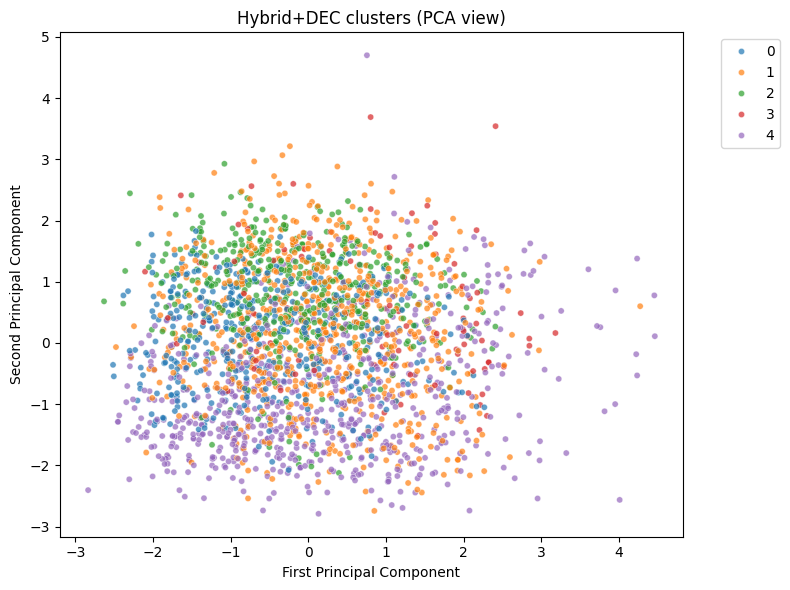


✅ All results stored in clustering_all_models_20250728_155247.xlsx

📋 SAMPLE RESULTS:
Unique_ID          Parent_Industry       Job_Function  KM_cluster  GMM_cluster  Hybrid_DEC
kims_0001                  Finance General Management           2            0           4
kims_0002        Retail & Consumer      It/Technology           2            0           4
kims_0003 Information & Technology General Management           2            0           4
kims_0004               Healthcare      It/Technology           2            4           4
kims_0005        Retail & Consumer      It/Technology           2            4           0
kims_0006            Manufacturing      It/Technology           2            0           0
kims_0007 Information & Technology   Customer Service           2            0           0
kims_0008              Engineering General Management           2            3           0
kims_0009        Retail & Consumer General Management           2            0           1
kim

In [22]:
# clustering_suite.py
import warnings, os, json, numpy as np, pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster     import KMeans, DBSCAN
from sklearn.mixture     import GaussianMixture
from sklearn.metrics     import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
from collections import Counter
warnings.filterwarnings("ignore")

# ---------------------- 0.  utility helpers --------------------------
def scores(X, labels):
    """Return Silhouette, Calinski-Harabasz, Davies-Bouldin (-1 if bad)."""
    if len(set(labels)) < 2:                   # need ≥2 clusters
        return -1, -1, 9999
    sil = silhouette_score(X, labels)
    cal = calinski_harabasz_score(X, labels)
    db  = davies_bouldin_score(X, labels)
    return sil, cal, db

# FIXED: Changed parameter names to match the keyword arguments
def add_metrics(df, name, k, silhouette, calinski, davies):
    df.loc[len(df)] = [name, k, silhouette, calinski, davies]

# ---------------------- 1.  classic models ---------------------------
def run_kmeans(X, k):
    model = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = model.fit_predict(X)
    sil, cal, db = scores(X, labels)
    return model, labels, dict(silhouette=sil, calinski=cal, davies=db)

def run_gmm(X, k):
    model   = GaussianMixture(n_components=k, covariance_type="full", random_state=42)
    labels  = model.fit_predict(X)
    probs   = model.predict_proba(X)           # soft assignment
    sil, cal, db = scores(X, labels)
    return model, labels, probs, dict(silhouette=sil, calinski=cal, davies=db)

def run_dbscan(X, eps=0.5, min_samples=10):
    model  = DBSCAN(eps=eps, min_samples=min_samples)
    labels = model.fit_predict(X)
    sil, cal, db = scores(X, labels)
    return model, labels, dict(silhouette=sil, calinski=cal, davies=db)

# ---------------------- 2.  voting hybrid ----------------------------
def hybrid_voting(km_labels, gmm_labels, db_labels):
    """Majority vote; noise (-1) from DBSCAN ignored."""
    final = []
    for a,b,c in zip(km_labels, gmm_labels, db_labels):
        votes = [a,b] + ([] if c==-1 else [c])
        final.append(Counter(votes).most_common(1)[0][0])
    return np.array(final)

# ---------------------- 3.  Deep Embedded Clustering -----------------
      # ---------------------- 3.  Deep Embedded Clustering - FIXED ---------

# ---------------------- 3.  Deep Embedded Clustering - COMPLETELY FIXED ---------
def run_DEC(X, n_clusters, latent_dim=10, epochs=20, batch_size=256):
    """
    Minimal DEC implementation using Functional API (no Sequential model issues)
    """
    import tensorflow as tf
    from tensorflow.keras import layers, models, losses, optimizers
    
    input_dim = X.shape[1]
    
    # FIXED: Use Functional API instead of Sequential
    # Encoder
    encoder_input = layers.Input(shape=(input_dim,))
    x = layers.Dense(500, activation='relu')(encoder_input)
    x = layers.Dense(200, activation='relu')(x)
    encoder_output = layers.Dense(latent_dim, activation='relu')(x)
    encoder = models.Model(encoder_input, encoder_output, name="encoder")
    
    # Decoder
    decoder_input = layers.Input(shape=(latent_dim,))
    x = layers.Dense(200, activation='relu')(decoder_input)
    x = layers.Dense(500, activation='relu')(x)
    decoder_output = layers.Dense(input_dim, activation='linear')(x)
    decoder = models.Model(decoder_input, decoder_output, name="decoder")
    
    # Autoencoder (combining encoder and decoder)
    autoencoder_input = layers.Input(shape=(input_dim,))
    encoded = encoder(autoencoder_input)
    decoded = decoder(encoded)
    autoencoder = models.Model(autoencoder_input, decoded, name="autoencoder")
    
    # Compile and train
    autoencoder.compile(optimizer=optimizers.Adam(1e-3), loss=losses.MeanSquaredError())
    autoencoder.fit(X, X, epochs=epochs, batch_size=batch_size, verbose=0)
    
    # Get embeddings and cluster
    Z = encoder.predict(X, verbose=0)
    km_model, km_labels, _ = run_kmeans(Z, n_clusters)
    sil, cal, db = scores(Z, km_labels)
    return encoder, km_model, km_labels, Z, dict(silhouette=sil, calinski=cal, davies=db)

################
# ---------------------- 4.  master pipeline --------------------------
def full_clustering_pipeline(dataframe, id_cols=None,
                             k_range = range(3,11),
                             dbscan_params = {'eps':0.6,'min_samples':10},
                             dec_epochs = 25):
    """
    dataframe :  pandas DataFrame with ONLY features (id columns optional)
    id_cols   :  columns to keep but NOT use for clustering
    returns   :  dictionary of all results + Excel file
    """
    if id_cols is None: id_cols=[]
    df = dataframe.copy()
    id_part = df[id_cols] if id_cols else None
    feat_df = df.drop(columns=id_cols) if id_cols else df
    
    print(f"📊 Processing {len(df)} rows with {len(feat_df.columns)} features")
    
    # encode categoricals → numeric (simple label-encoding)
    for col in feat_df.columns:
        if feat_df[col].dtype=='object':
            feat_df[col] = feat_df[col].astype(str).fillna('NA')
            feat_df[col] = pd.factorize(feat_df[col])[0]
        else:
            feat_df[col] = feat_df[col].fillna(feat_df[col].median())
    
    scaler = StandardScaler();  X = scaler.fit_transform(feat_df.values)
    
    metric_table = pd.DataFrame(columns=["Model","K/eps","Silhouette","Calinski","Davies"])
    
    print(f"🔍 Testing clustering methods...")
    
    # 1-a  K-means & GMM grid search
    best_sil, best_k = -1, None
    for k in k_range:
        km, km_lbl, km_m = run_kmeans(X,k)
        add_metrics(metric_table,f"KMeans-{k}",k,**km_m)  # Now works with keyword args
        if km_m['silhouette']>best_sil: best_sil,best_k = km_m['silhouette'],k
        
        gmm, gmm_lbl, gmm_prob, gmm_m = run_gmm(X,k)
        add_metrics(metric_table,f"GMM-{k}",k,**gmm_m)
        if gmm_m['silhouette']>best_sil: best_sil,best_k = gmm_m['silhouette'],k
        
    print(f"🏆 Best K found: {best_k} (Silhouette: {best_sil:.3f})")
        
    # keep best km/gmm for hybrids
    best_km   = KMeans(n_clusters=best_k, n_init=20, random_state=42).fit(X)
    best_km_lbl = best_km.labels_
    best_gmm   = GaussianMixture(n_components=best_k, random_state=42).fit(X)
    best_gmm_lbl = best_gmm.predict(X)
    
    # 1-b  DBSCAN
    print(f"🔗 Running DBSCAN...")
    dbs, db_lbl, db_m = run_dbscan(X, **dbscan_params)
    add_metrics(metric_table,"DBSCAN",f"eps={dbscan_params['eps']}",**db_m)
    
    # 2    Hybrid voting
    print(f"🗳️  Creating hybrid ensemble...")
    hybrid_lbl = hybrid_voting(best_km_lbl, best_gmm_lbl, db_lbl)
    h_sil,h_cal,h_db = scores(X, hybrid_lbl)
    add_metrics(metric_table,"Hybrid-Vote",best_k,h_sil,h_cal,h_db)
    
    # 3    DEC on original features
    print(f"🧠 Running Deep Embedded Clustering...")
    enc, dec_km, dec_lbl, Z, dec_m = run_DEC(X, n_clusters=best_k,
                                             epochs=dec_epochs)
    add_metrics(metric_table,"DEC",best_k,**dec_m)
    
    # 4    Hybrid + DEC  (vote between DEC and earlier hybrid)
    print(f"🔄 Creating final hybrid...")
    hybrid2 = hybrid_voting(dec_lbl, best_km_lbl, best_gmm_lbl)
    h2_sil,h2_cal,h2_db = scores(X, hybrid2)
    add_metrics(metric_table,"Hybrid+DEC",best_k,h2_sil,h2_cal,h2_db)
    
    # ------------- Build output frame ----------------
    out = dataframe.copy()
    out["KM_cluster"]      = best_km_lbl
    out["GMM_cluster"]     = best_gmm_lbl
    out["DBSCAN_cluster"]  = db_lbl
    out["Hybrid_cluster"]  = hybrid_lbl
    out["DEC_cluster"]     = dec_lbl
    out["Hybrid_DEC"]      = hybrid2
    
    # Display metrics summary
    print(f"\n📈 CLUSTERING RESULTS SUMMARY:")
    print(metric_table.to_string(index=False))
    
    # quick 2-D view of best model
    pca = PCA(2).fit_transform(X)
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=pca[:,0],y=pca[:,1], hue=hybrid2, palette="tab10", s=20, alpha=0.7)
    plt.title("Hybrid+DEC clusters (PCA view)")
    plt.xlabel("First Principal Component")
    plt.ylabel("Second Principal Component")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    
    # Excel export
    ts  = datetime.now().strftime("%Y%m%d_%H%M%S")
    fname = f"clustering_all_models_{ts}.xlsx"
    with pd.ExcelWriter(fname, engine="openpyxl") as writer:
        out.to_excel(writer, sheet_name="Clusters", index=False)
        metric_table.to_excel(writer, sheet_name="Metrics", index=False)
        
        # Add cluster summary
        cluster_summary = []
        for method in ["KM_cluster", "GMM_cluster", "DBSCAN_cluster", "Hybrid_cluster", "DEC_cluster", "Hybrid_DEC"]:
            if method in out.columns:
                cluster_counts = out[method].value_counts().sort_index()
                for cluster_id, count in cluster_counts.items():
                    cluster_summary.append({
                        'Method': method,
                        'Cluster_ID': cluster_id,
                        'Count': count,
                        'Percentage': f"{count/len(out)*100:.1f}%"
                    })
        
        summary_df = pd.DataFrame(cluster_summary)
        summary_df.to_excel(writer, sheet_name="Cluster_Summary", index=False)
        
        # GMM weights
        pd.DataFrame(best_gmm.weights_, columns=["ComponentWeights"]).to_excel(
            writer, sheet_name="GMM_weights", index=False)
    
    print(f"\n✅ All results stored in {fname}")
    
    return {
        "data_with_clusters": out,
        "metrics": metric_table,
        "filesaved": fname,
        "models": {
            "kmeans": best_km,
            "gmm":    best_gmm,
            "dbscan": dbs,
            "dec_encoder": enc
        }
    }

# ---------------------- Usage with your data -------------------------
# Load your Excel data
raw = pd.read_excel("./las3.18.xlsx")
print(f"📁 Loaded {len(raw)} friends from Excel")

# Run the complete clustering pipeline
result = full_clustering_pipeline(raw, id_cols=["Unique_ID"])

# Show sample results
print(f"\n📋 SAMPLE RESULTS:")
sample_cols = ["Unique_ID", "Parent_Industry", "Job_Function", "KM_cluster", "GMM_cluster", "Hybrid_DEC"]
if all(col in result["data_with_clusters"].columns for col in sample_cols):
    print(result["data_with_clusters"][sample_cols].head(10).to_string(index=False))


In [2]:
pip install gensim


     --------------------------------------- 24.0/24.0 MB 13.1 MB/s eta 0:00:00
     --------------------------------------- 15.8/15.8 MB 14.9 MB/s eta 0:00:00
     --------------------------------------- 46.2/46.2 MB 16.8 MB/s eta 0:00:00
     ---------------------------------------- 61.9/61.9 kB ? eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.1.3
    Uninstalling numpy-2.1.3:
      Successfully uninstalled numpy-2.1.3
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\abhinash\\Documents\\Internship\\clustering\\.venv\\Lib\\site-packages\\~umpy.libs\\libscipy_openblas64_-c16e4918366c6bc1f1cd71e28ca36fc0.dll'
Check the permissions.


[notice] A new release of pip available: 22.3 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
